In [16]:
from google.colab import files # Open a file upload dialog uploaded = files.upload()

In [17]:
uploaded = files.upload()

Saving train.csv to train.csv


In [18]:
df= pd.read_csv("test.csv")
print(df.head(10))

      id                                              title  Rating maincateg  \
0   2242                            Casuals For Men  (Blue)     3.8       Men   
1  20532                           Women Black Flats Sandal     3.9     Women   
2  10648                           Women Gold Wedges Sandal     3.9     Women   
3  20677  Men's Height Increasing High Heel Formal Party...     3.9       Men   
4  12593                             Loafers For Men  (Tan)     3.9       Men   
5  11159                      Canvas Shoes For Men  (Black)     3.9       Men   
6  10680  Combo Pack Of 2 Casual Shoes Slip On Sneakers ...     3.9       Men   
7   6433  ARYA - DIFFERENT EDGE Bellies For Women  (Purple)     4.2     Women   
8   2794  Latest Collection, Comfortable & Fashionable B...     3.9     Women   
9  11579                 MOCCASSIN Slip On For Men  (Black)     3.8       Men   

   platform  actprice1  norating1  noreviews1  star_5f  star_4f  star_3f  \
0  Flipkart        999      2792

In [19]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Load dataset
# Replace with your actual file path
data = pd.read_csv("test.csv")

# Step 2: Handle missing values (optional, depends on dataset)
data = data.dropna()

# Step 3: Select numeric features only
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Step 4: Standardize the data (important for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Step 5: Apply PCA
pca = PCA(n_components=2)  # choose number of components
principal_components = pca.fit_transform(scaled_data)

# Step 6: Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=principal_components,
                      columns=['PC1', 'PC2'])

# Step 7: Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Step 8: Combine PCA results with original dataset (optional)
final_df = pd.concat([pca_df, data.reset_index(drop=True)], axis=1)

# Display first few rows
print(final_df.head(10))


Explained variance ratio: [0.61697013 0.12937877]
        PC1       PC2     id  \
0  5.904129 -0.256028   2242   
1  0.100492 -0.117887  20532   
2 -0.480965  0.079071  10648   
3 -0.565940  1.071976  20677   
4 -0.134941 -1.076096  12593   
5 -0.562231 -1.076200  11159   
6 -0.429980  0.741032  10680   
7 -0.627507  2.173274   6433   
8 -0.258280 -1.355755   2794   
9  0.084582  0.507840  11579   

                                               title  Rating maincateg  \
0                            Casuals For Men  (Blue)     3.8       Men   
1                           Women Black Flats Sandal     3.9     Women   
2                           Women Gold Wedges Sandal     3.9     Women   
3  Men's Height Increasing High Heel Formal Party...     3.9       Men   
4                             Loafers For Men  (Tan)     3.9       Men   
5                      Canvas Shoes For Men  (Black)     3.9       Men   
6  Combo Pack Of 2 Casual Shoes Slip On Sneakers ...     3.9       Men   
7  AR

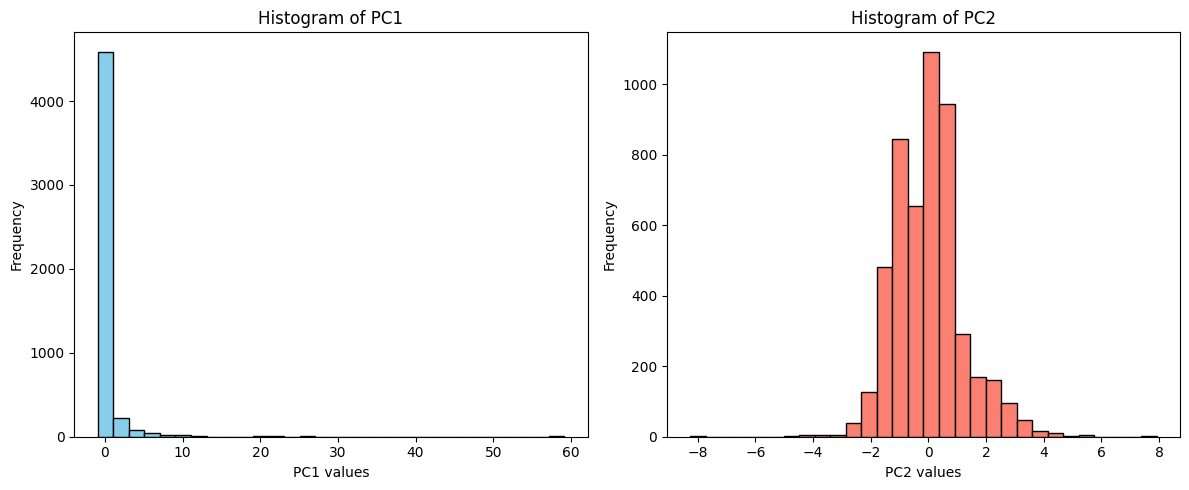

In [20]:
import matplotlib.pyplot as plt

# Plot histogram for PC1
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pca_df['PC1'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of PC1')
plt.xlabel('PC1 values')
plt.ylabel('Frequency')

# Plot histogram for PC2
plt.subplot(1,2,2)
plt.hist(pca_df['PC2'], bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of PC2')
plt.xlabel('PC2 values')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


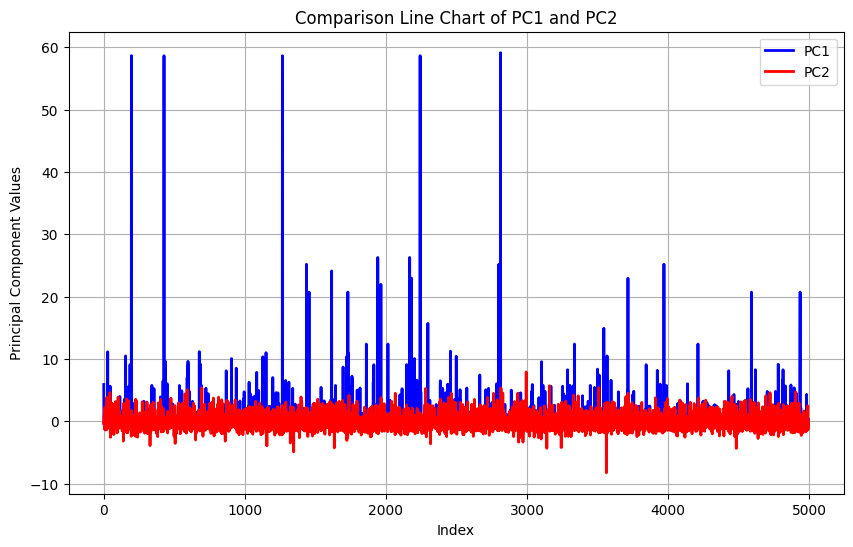

In [7]:
import matplotlib.pyplot as plt

# Assuming pca_df contains 'PC1' and 'PC2'
plt.figure(figsize=(10,6))

plt.plot(pca_df.index, pca_df['PC1'], label='PC1', color='blue', linewidth=2)
plt.plot(pca_df.index, pca_df['PC2'], label='PC2', color='red', linewidth=2)

plt.title('Comparison Line Chart of PC1 and PC2')
plt.xlabel('Index')
plt.ylabel('Principal Component Values')
plt.legend()
plt.grid(True)
plt.show()


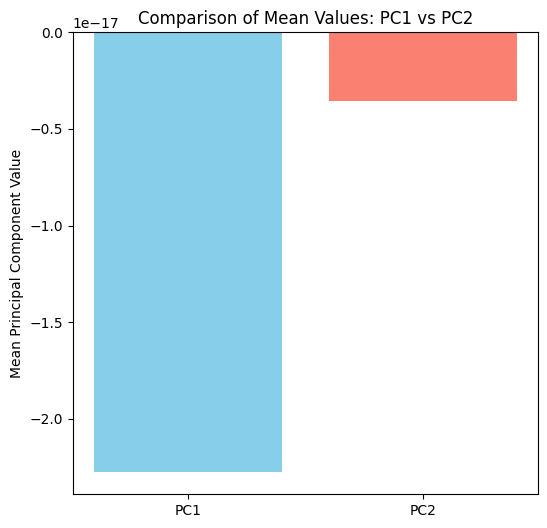

In [8]:
import matplotlib.pyplot as plt

# Calculate mean values of PC1 and PC2
pc1_mean = pca_df['PC1'].mean()
pc2_mean = pca_df['PC2'].mean()

# Create bar chart
plt.figure(figsize=(6,6))
plt.bar(['PC1', 'PC2'], [pc1_mean, pc2_mean], color=['skyblue','salmon'])

plt.title('Comparison of Mean Values: PC1 vs PC2')
plt.ylabel('Mean Principal Component Value')
plt.show()


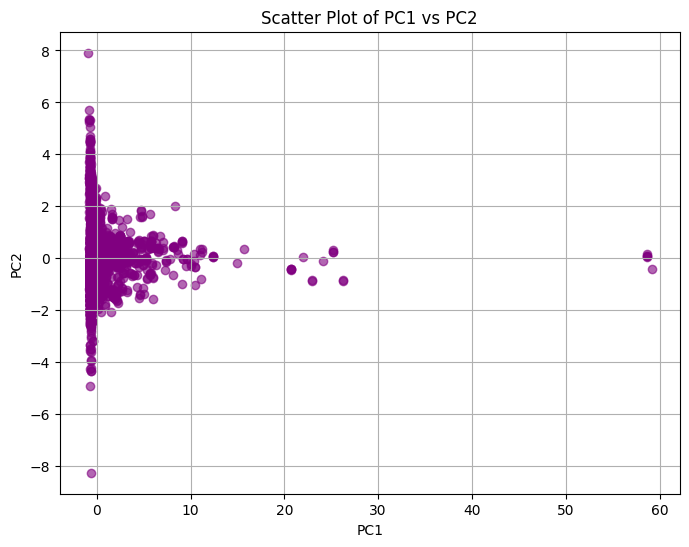

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, color='purple')
plt.title('Scatter Plot of PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()


/tmp/ipykernel_5597/2215045518.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pca_df['PC1'], pca_df['PC2']], labels=['PC1','PC2'])


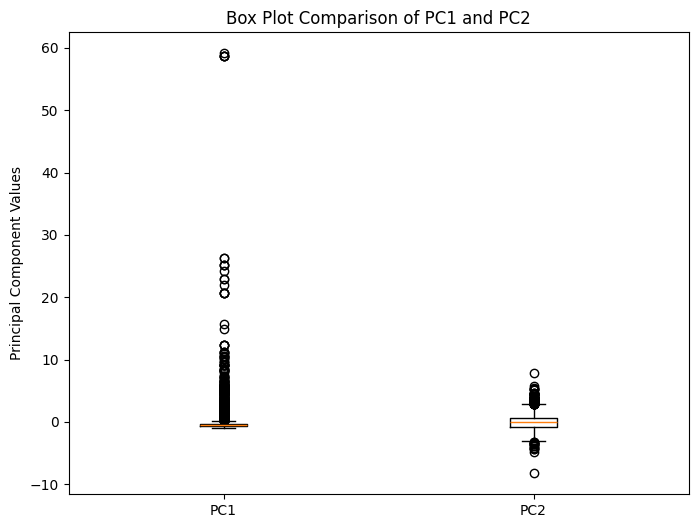

In [22]:
plt.figure(figsize=(8,6))
plt.boxplot([pca_df['PC1'], pca_df['PC2']], labels=['PC1','PC2'])
plt.title('Box Plot Comparison of PC1 and PC2')
plt.ylabel('Principal Component Values')
plt.show()


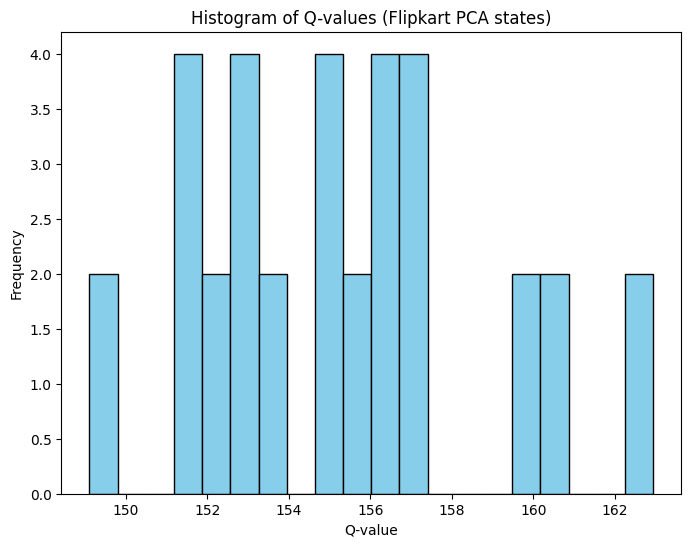

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have PCA results in pca_df with columns 'PC1' and 'PC2'
# Example: pca_df = pd.DataFrame(principal_components, columns=['PC1','PC2'])

# Step 1: Discretize PC1 and PC2 into bins (states)
pc1_bins = np.digitize(pca_df['PC1'], bins=np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 10))
pc2_bins = np.digitize(pca_df['PC2'], bins=np.linspace(pca_df['PC2'].min(), pca_df['PC2'].max(), 10))

# Define states as pairs of (pc1_bin, pc2_bin)
states = list(zip(pc1_bins, pc2_bins))
n_states = len(set(states))
n_actions = 2  # arbitrary: e.g., "Action A" or "Action B"

# Step 2: Initialize Q-table
Q = np.zeros((n_states, n_actions))

# Step 3: Hyperparameters
learning_rate = 0.8
discount_factor = 0.95
episodes = 500
epsilon = 0.1

# Step 4: Map states to indices
state_to_index = {s:i for i,s in enumerate(set(states))}

# Step 5: Q-learning loop
for episode in range(episodes):
    for s in states:
        state_idx = state_to_index[s]

        # Choose action (epsilon-greedy)
        if np.random.uniform(0,1) < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q[state_idx,:])

        # Reward: here we can use PC1+PC2 as a proxy reward
        reward = s[0] + s[1]

        # Next state (just loop through states sequentially)
        next_state_idx = (state_idx + 1) % n_states

        # Update Q-table
        Q[state_idx, action] = Q[state_idx, action] + learning_rate * (
            reward + discount_factor * np.max(Q[next_state_idx,:]) - Q[state_idx, action]
        )

# Step 6: Visualize Q-values in histogram
plt.figure(figsize=(8,6))
plt.hist(Q.flatten(), bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Q-values (Flipkart PCA states)")
plt.xlabel("Q-value")
plt.ylabel("Frequency")
plt.show()


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# Load dataset
data = pd.read_csv("test.csv")

# Inspect columns
print(data.columns)

# Drop rows where target is NaN
data = data.dropna(subset=[target_col])

X = data.drop(target_col, axis=1)
y = data[target_col]

# Encode categorical features
X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Encode categorical features
X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Choose classifier or regressor depending on target type
if y.dtype == 'object':   # categorical target
    model = RandomForestClassifier(n_estimators=100, random_state=42)
else:                     # numeric target
    model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
if y.dtype == 'object':
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


Index(['id', 'title', 'Rating', 'maincateg', 'platform', 'price1', 'actprice1',
       'Offer %', 'norating1', 'noreviews1', 'star_5f', 'star_4f', 'star_3f',
       'star_2f', 'star_1f', 'fulfilled1'],
      dtype='object')


NameError: name 'target_col' is not defined